# Job Data Cleaning (Merged)

This notebook merges the stronger job-specific cleaning from `data_cleaning_job.ipynb`
with the better loader, validation, and save flow from `data_cleaning_jobs.ipynb`.

It is structured to run top-to-bottom without the duplicated or broken cells from the
earlier versions.


## Load Data

The loader prefers `MCF-*.json` files anywhere under `../../data`, which keeps the
merged notebook aligned with the project dataset and avoids mixing in unrelated JSON
files when the folder layout changes.


In [93]:
import json
import re
from collections import Counter
from difflib import SequenceMatcher
from pathlib import Path

import pandas as pd
from bs4 import BeautifulSoup


DATA_ROOT = Path("../../data")
OUTPUT_DIR = DATA_ROOT / "cleaned_data"
RAW_SKILLS_OUTPUT = DATA_ROOT / "job_skills_raw.xlsx"
CLEANED_SKILLS_OUTPUT = DATA_ROOT / "job_skills_cleaned_frequency.xlsx"


def clean_html(text):
    if not isinstance(text, str):
        return ""

    cleaned = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    cleaned = cleaned.replace("\xa0", " ")
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned


def find_job_files(data_root):
    mcf_files = sorted(
        path for path in data_root.rglob("*.json")
        if path.name.startswith("MCF-")
    )
    if mcf_files:
        return mcf_files

    job_dir = data_root / "job"
    if job_dir.exists():
        return sorted(job_dir.glob("*.json"))

    return []


def extract_named_values(items, *keys):
    values = []

    if not isinstance(items, list):
        return values

    for item in items:
        if isinstance(item, dict):
            for key in keys:
                value = item.get(key)
                if value:
                    values.append(str(value).strip())
                    break
        elif isinstance(item, str) and item.strip():
            values.append(item.strip())

    return values


def load_jobs_dataframe(data_root=DATA_ROOT):
    rows = []
    job_files = find_job_files(data_root)

    for file_path in job_files:
        with open(file_path, "r", encoding="utf-8") as handle:
            job = json.load(handle)

        salary_info = job.get("salary") or {}
        salary_type = (salary_info.get("type") or {}).get("salaryType")
        metadata = job.get("metadata") or {}

        rows.append(
            {
                "uuid": job.get("uuid") or file_path.stem,
                "title": job.get("title"),
                "description": clean_html(job.get("description")),
                "minimum_years_experience": job.get("minimumYearsExperience"),
                "skills": extract_named_values(job.get("skills"), "skill"),
                "employment_types": extract_named_values(
                    job.get("employmentTypes"), "employmentType"
                ),
                "position_levels": extract_named_values(
                    job.get("positionLevels"), "position"
                ),
                "flexible_work_arrangements": extract_named_values(
                    job.get("flexibleWorkArrangements"),
                    "flexibleWorkArrangement",
                    "arrangement",
                    "name",
                ),
                "categories": extract_named_values(
                    job.get("categories"), "category"
                ),
                "ssoc_code": job.get("ssocCode"),
                "ssoc_version": job.get("ssocVersion"),
                "salary_minimum": salary_info.get("minimum"),
                "salary_maximum": salary_info.get("maximum"),
                "salary_type": salary_type,
                "posting_date": metadata.get("newPostingDate")
                or metadata.get("originalPostingDate"),
                "expiry_date": metadata.get("expiryDate"),
                "number_of_vacancies": job.get("numberOfVacancies"),
            }
        )

    return pd.DataFrame(rows), job_files


In [94]:
original_jobs_df, job_files = load_jobs_dataframe()

print(f"Discovered raw job JSON files: {len(job_files):,}")
print(f"Loaded job rows: {len(original_jobs_df):,}")

original_jobs_df.head(2)


Discovered raw job JSON files: 22,718
Loaded job rows: 22,718


,uuid,title,description,minimum_years_experience,skills,employment_types,position_levels,flexible_work_arrangements,categories,ssoc_code,ssoc_version,salary_minimum,salary_maximum,salary_type,posting_date,expiry_date,number_of_vacancies
0,4a68226fc8b1d6f39bcf78451f7bc198,Sales Administrator,Serve as administrator / key operator for all ...,1,"[Sales, Microsoft Office, Microsoft Excel, Tra...",[Full Time],[Executive],[],"[Hospitality, Sales / Retail]",33224,2020v2,3000,3200,Monthly,2026-01-25,2026-02-24,1
1,4726f24811127db6967fd1c07ec7ae77,Assistant Field Engineer(Construction),Our Company: Our company develops ICT(Informat...,1,"[Troubleshooting, Construction, Hardware, Elec...",[Full Time],[Fresh/entry level],[],"[Customer Service, Engineering, Professional S...",21499,2020v2,2500,4500,Monthly,2026-01-27,2026-02-26,1


## Job Cleaning

This stage keeps the stronger rules from the job-specific notebook:

- restrict to fresh-graduate friendly roles (`0` or `1` year experience)
- remove internships using both text and employment-type signals
- keep only rows with meaningful descriptions
- deduplicate repeated job postings before feature engineering


In [95]:
jobs_df = original_jobs_df.copy()

jobs_df = jobs_df[jobs_df["minimum_years_experience"].isin([0, 1])].copy()
after_experience_filter = len(jobs_df)

jobs_df = jobs_df.dropna(subset=["title", "description"]).copy()

jobs_df["title_clean"] = jobs_df["title"].str.lower()
jobs_df["description_clean"] = jobs_df["description"].str.lower()

valid_desc = jobs_df["description_clean"].str.split().str.len() >= 10
jobs_df = jobs_df[valid_desc].copy()
after_description_filter = len(jobs_df)

intern_mask = (
    jobs_df["title_clean"].str.contains(
        r"\bintern(?:ship)?s?\b",
        regex=True,
        na=False,
    )
    | jobs_df["description_clean"].str.contains(
        r"\bintern(?:ship)?s?\b",
        regex=True,
        na=False,
    )
    | jobs_df["employment_types"].apply(
        lambda values: isinstance(values, list)
        and any("intern" in str(item).lower() for item in values)
    )
)

postgraduate_title_mask = jobs_df["title_clean"].str.contains(
    r"\b(?:postdoc(?:toral)?|research fellow|senior research fellow|assistant professor|associate professor|professor|lecturer|medical doctor)\b",
    regex=True,
    na=False,
)
postgraduate_requirement_mask = jobs_df["description_clean"].str.contains(
    r"(?:require(?:ment|s|d)?|minimum|preferred|qualification|qualifications|possess|holding|hold|must have|with|degree in).{0,120}\b(?:ph\.?d|doctor(?:al|ate)|master(?:'s)? degree|masters degree|master degree|postgraduate|graduate diploma|graduate certificate)\b",
    regex=True,
    na=False,
)

jobs_df = jobs_df[
    ~(intern_mask | postgraduate_title_mask | postgraduate_requirement_mask)
].copy()
after_undergraduate_filter = len(jobs_df)

jobs_df = jobs_df.drop_duplicates(
    subset=["title", "description"],
    keep="first",
).copy()
after_deduplication = len(jobs_df)

jobs_df["has_flexible_work"] = jobs_df["flexible_work_arrangements"].apply(
    lambda values: bool(values) if isinstance(values, list) else False
)
jobs_df["ssoc_3d"] = jobs_df["ssoc_code"].astype(str).str[:3]

print(f"After experience filter: {after_experience_filter:,}")
print(f"After description filter: {after_description_filter:,}")
print(f"After undergrad-only filter: {after_undergraduate_filter:,}")
print(f"After deduplication: {after_deduplication:,}")

jobs_df.head(2)


After experience filter: 9,477
After description filter: 9,476
After undergrad-only filter: 8,834
After deduplication: 7,115


,uuid,title,description,minimum_years_experience,skills,employment_types,position_levels,flexible_work_arrangements,categories,ssoc_code,ssoc_version,salary_minimum,salary_maximum,salary_type,posting_date,expiry_date,number_of_vacancies,title_clean,description_clean,has_flexible_work,ssoc_3d
0,4a68226fc8b1d6f39bcf78451f7bc198,Sales Administrator,Serve as administrator / key operator for all ...,1,"[Sales, Microsoft Office, Microsoft Excel, Tra...",[Full Time],[Executive],[],"[Hospitality, Sales / Retail]",33224,2020v2,3000,3200,Monthly,2026-01-25,2026-02-24,1,sales administrator,serve as administrator / key operator for all ...,False,332
1,4726f24811127db6967fd1c07ec7ae77,Assistant Field Engineer(Construction),Our Company: Our company develops ICT(Informat...,1,"[Troubleshooting, Construction, Hardware, Elec...",[Full Time],[Fresh/entry level],[],"[Customer Service, Engineering, Professional S...",21499,2020v2,2500,4500,Monthly,2026-01-27,2026-02-26,1,assistant field engineer(construction),our company: our company develops ict(informat...,False,214


## Employment Type And Salary Features

This section keeps the contract/work-type logic from `data_cleaning_job.ipynb` and the
validation-friendly summary flow from `data_cleaning_jobs.ipynb`.


In [96]:
contract_types = ["Permanent", "Contract", "Temporary", "Freelance"]
work_types = ["Full Time", "Part Time"]


def extract_contract_type(values):
    if isinstance(values, list):
        for item in values:
            if item in contract_types:
                return item
    return None


def extract_work_type(values):
    if isinstance(values, list):
        for item in values:
            if item in work_types:
                return item
    return None


jobs_df["contract_type"] = (
    jobs_df["employment_types"].apply(extract_contract_type).fillna("Unknown")
)
jobs_df["work_type"] = (
    jobs_df["employment_types"].apply(extract_work_type).fillna("Unknown")
)

jobs_df = jobs_df[
    ~(
        (jobs_df["contract_type"] == "Unknown")
        & (jobs_df["work_type"] == "Unknown")
    )
].copy()

jobs_df["salary_minimum"] = pd.to_numeric(
    jobs_df["salary_minimum"],
    errors="coerce",
)
jobs_df["salary_maximum"] = pd.to_numeric(
    jobs_df["salary_maximum"],
    errors="coerce",
)
jobs_df["avg_salary"] = jobs_df[
    ["salary_minimum", "salary_maximum"]

].mean(axis=1) .round().astype("Int64")

known_work_type = jobs_df["work_type"] != "Unknown"
ssoc_mode = (
    jobs_df[known_work_type]
    .groupby("ssoc_3d")["work_type"]
    .agg(lambda values: values.mode().iat[0] if not values.mode().empty else None)
    .dropna()
)

salary_medians = jobs_df.groupby("work_type")["avg_salary"].median()
full_time_median = salary_medians.get("Full Time")
part_time_median = salary_medians.get("Part Time")

if pd.notna(full_time_median) and pd.notna(part_time_median):
    salary_threshold = (full_time_median + part_time_median) / 2
else:
    salary_threshold = jobs_df["avg_salary"].median()


def impute_work_type(row):
    if row["work_type"] != "Unknown":
        return row["work_type"]

    ssoc_value = ssoc_mode.get(row["ssoc_3d"])
    if pd.notna(ssoc_value):
        return ssoc_value

    if pd.notna(row["avg_salary"]) and pd.notna(salary_threshold):
        return "Full Time" if row["avg_salary"] >= salary_threshold else "Part Time"

    return "Unknown"


jobs_df["work_type"] = jobs_df.apply(impute_work_type, axis=1)

print("Contract types:")
print(jobs_df["contract_type"].value_counts(dropna=False))
print()
print("Work types:")
print(jobs_df["work_type"].value_counts(dropna=False))


Contract types:
contract_type
Unknown      3136
Permanent    2782
Contract      809
Temporary     332
Freelance      56
Name: count, dtype: int64

Work types:
work_type
Full Time    6458
Part Time     657
Name: count, dtype: int64


## Skill Cleaning

The merged skill pipeline keeps:

- raw skill extraction and export
- normalized skill cleanup
- soft-skill collapsing
- fuzzy within-row deduplication
- frequency filtering and `num_skills` thresholding


In [97]:
def base_clean_skill(skill):
    if not isinstance(skill, str):
        return None

    skill = skill.lower().strip()
    return skill or None


jobs_df["skills_clean"] = jobs_df["skills"].apply(
    lambda values: sorted(
        {
            base_clean_skill(skill)
            for skill in values
            if base_clean_skill(skill)
        }
    )
    if isinstance(values, list)
    else []
)

raw_skill_counts = Counter(
    skill for values in jobs_df["skills_clean"] for skill in values
)
raw_skill_freq_df = (
    pd.DataFrame(
        raw_skill_counts.items(),
        columns=["skill", "count"],
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

raw_skill_freq_df.to_excel(RAW_SKILLS_OUTPUT, index=False)

print(f"Saved raw skill frequencies to: {RAW_SKILLS_OUTPUT.resolve()}")
raw_skill_freq_df.head(10)


Saved raw skill frequencies to: /Users/jiaxin/Desktop/DSA4264/DSA4264 ME/DSA4264-Project/data/job_skills_raw.xlsx


,skill,count
0,team player,2857
1,customer service,2114
2,interpersonal skills,2059
3,communication skills,1722
4,microsoft office,1677
5,inventory,1511
6,microsoft excel,1461
7,sales,1232
8,leadership,1231
9,administration,1166


In [98]:
core_soft_skills = [
    "communication",
    "leadership",
    "presentation",
    "interpersonal",
    "customer service",
    "problem solving",
    "analytical",
    "teamwork",
    "independence",
]

exact_keep = {
    "project management",
    "management accounting",
    "financial management",
    "risk management",
    "data management",
}

junk_skills = {
    "team player",
    "able to work independently",
    "physically fit",
}


def normalize_skill(skill):
    if not isinstance(skill, str):
        return None

    skill = skill.lower().strip()
    skill = skill.replace("&", "and")
    skill = re.sub(r"[^\w\s]", "", skill)
    skill = re.sub(r"\s+", " ", skill).strip()

    if not skill or skill in junk_skills:
        return None

    if skill in exact_keep:
        return skill

    for core in core_soft_skills:
        if core in skill:
            return core

    skill = re.sub(r"\bskills\b", "", skill)
    skill = re.sub(r"\s+", " ", skill).strip()
    return skill or None


def is_similar(left, right, threshold=0.8):
    return SequenceMatcher(None, left, right).ratio() > threshold


def dedupe_similar_skills(skill_list):
    unique = []

    for skill in skill_list:
        if not any(is_similar(skill, existing) for existing in unique):
            unique.append(skill)

    return unique


jobs_df["skills_clean"] = jobs_df["skills_clean"].apply(
    lambda values: dedupe_similar_skills(
        sorted(
            {
                normalize_skill(skill)
                for skill in values
                if normalize_skill(skill)
            }
        )
    )
    if isinstance(values, list)
    else []
)

cleaned_skill_counts = Counter(
    skill for values in jobs_df["skills_clean"] for skill in values
)
valid_skills = {
    skill
    for skill, count in cleaned_skill_counts.items()
    if count >= 3
}

jobs_df["skills_clean"] = jobs_df["skills_clean"].apply(
    lambda values: [skill for skill in values if skill in valid_skills]
)
jobs_df["num_skills"] = jobs_df["skills_clean"].apply(len)

jobs_df = jobs_df[jobs_df["num_skills"] >= 3].copy()

cleaned_skill_freq_df = (
    pd.DataFrame(
        Counter(
            skill for values in jobs_df["skills_clean"] for skill in values
        ).items(),
        columns=["skill", "count"],
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

cleaned_skill_freq_df.to_excel(CLEANED_SKILLS_OUTPUT, index=False)

print(jobs_df["num_skills"].describe())
print()
print(f"Saved cleaned skill frequencies to: {CLEANED_SKILLS_OUTPUT.resolve()}")
cleaned_skill_freq_df.head(10)


count    7104.000000
mean       12.758868
std         3.218583
min         3.000000
25%        10.000000
50%        13.000000
75%        15.000000
max        20.000000
Name: num_skills, dtype: float64

Saved cleaned skill frequencies to: /Users/jiaxin/Desktop/DSA4264/DSA4264 ME/DSA4264-Project/data/job_skills_cleaned_frequency.xlsx


,skill,count
0,communication,2521
1,customer service,2308
2,interpersonal,2080
3,microsoft office,1677
4,inventory,1511
5,microsoft excel,1461
6,leadership,1283
7,sales,1232
8,administration,1166
9,housekeeping,1079


In [99]:
# remove the [ ] in the columns: employment_types, position_levels, categories	
list_cols = ["employment_types", "position_levels", "categories"]

for col in list_cols:
    jobs_df[col] = jobs_df[col].apply(
        lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x
    )


## Save Cleaned Output

The merged notebook saves the cleaned jobs dataset to `../../data/cleaned_data/`.


In [105]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

jobs_df = jobs_df.drop(
    columns=[
        "title_clean",
        "description_clean",
        "flexible_work_arrangements",
        "salary_type",
        "skills_clean",
        "employment_types" # employment_types = work_type + contract_type
        # columns not shown: salary_type|occupationId|||ssecEqa|ssecFos
    ],
    errors="ignore",
)


column_order = [
    "uuid",
    "title",
    "categories",
    "description",
    "skills",
    "num_skills",
    "position_levels",
    # "employment_types",
    "work_type",
    "contract_type",
    "has_flexible_work",
    "number_of_vacancies",
    "minimum_years_experience",
    "salary_minimum",
    "salary_maximum",
    "avg_salary",
    "posting_date",
    "expiry_date",
    "ssoc_3d",
    "ssoc_code",
    "ssoc_version",
]

jobs_df = jobs_df.reindex(columns=column_order)


# convert posting_date and expiry_date to datetime, coerce errors to NaT
jobs_df["posting_date"] = pd.to_datetime(jobs_df["posting_date"], errors="coerce")
jobs_df["expiry_date"] = pd.to_datetime(jobs_df["expiry_date"], errors="coerce")




save the table

In [106]:
output_path = OUTPUT_DIR / "jobs_cleaned.pkl"

jobs_df.to_pickle(output_path)

print(f"Saved cleaned output to: {output_path.resolve()}")
print(f"Remaining cleaned rows: {len(jobs_df):,}")

pd.set_option('display.max_columns', None) # show all columns when displaying
jobs_df.head()


# jobs_df.columns

Saved cleaned output to: /Users/jiaxin/Desktop/DSA4264/DSA4264 ME/DSA4264-Project/data/cleaned_data/jobs_cleaned.pkl
Remaining cleaned rows: 7,104


,uuid,title,categories,description,skills,num_skills,position_levels,work_type,contract_type,has_flexible_work,number_of_vacancies,minimum_years_experience,salary_minimum,salary_maximum,avg_salary,posting_date,expiry_date,ssoc_3d,ssoc_code,ssoc_version
0,4a68226fc8b1d6f39bcf78451f7bc198,Sales Administrator,"Hospitality, Sales / Retail",Serve as administrator / key operator for all ...,"[Sales, Microsoft Office, Microsoft Excel, Tra...",13,Executive,Full Time,Unknown,False,1,1,3000,3200,3100,2026-01-25,2026-02-24,332,33224,2020v2
1,4726f24811127db6967fd1c07ec7ae77,Assistant Field Engineer(Construction),"Customer Service, Engineering, Professional Se...",Our Company: Our company develops ICT(Informat...,"[Troubleshooting, Construction, Hardware, Elec...",16,Fresh/entry level,Full Time,Unknown,False,1,1,2500,4500,3500,2026-01-27,2026-02-26,214,21499,2020v2
2,301389565abb7d8ddd32efebb58776cf,Electronic Keyboard Teacher,Education and Training,Teaching lessons to students at all skill leve...,"[Piano, Classical, Microsoft Excel, Teaching, ...",10,Non-executive,Full Time,Unknown,False,2,1,2500,3500,3000,2026-01-27,2026-02-26,362,36204,2020v2
3,dd32ada5c76ba97526adf85326a58793,F&B Executive,F&B,The applicant would be tasked on the following...,"[Microsoft Excel, Food Safety, Quality Assuran...",9,Fresh/entry level,Full Time,Unknown,False,5,0,3000,3300,3150,2026-01-27,2026-02-26,513,51311,2020v2
7,6275f8c4d86b02c3f7c1be399dfe3975,Kitchen Assistant @ Tuas | Rotating shift |Up ...,F&B,Description 📍 Location: Jalan Ahmad Ibrahim Ou...,"[Food Safety, Kitchen, Cooking, Housekeeping, ...",11,Non-executive,Full Time,Contract,False,20,1,2000,2800,2400,2026-01-28,2026-02-27,941,94101,2020v2


In [113]:
jobs_df.dtypes
# jobs_df["employment_types"].explode().unique()
# jobs_df["work_type"].unique() # ['Full Time', 'Part Time']
# jobs_df["contract_type"].unique() # 'Unknown', 'Contract', 'Permanent', 'Freelance', 'Temporary']
jobs_df["title"].explode().unique()
# jobs_df["skills"].explode().unique()

array(['Sales Administrator', 'Assistant Field Engineer(Construction)',
       'Electronic Keyboard Teacher', ...,
       '⚡⚡️ ENTRY-LEVEL SALES EXECUTIVE ⚡️',
       '⚡🌟 SALES ADVISOR – ENTRY LEVEL 🌟',
       '⚡🚀 SALES EXECUTIVE – ENTRY LEVEL 🚀'], shape=(6232,), dtype=object)

In [ ]:
# # for checking the employment types of a specific job by uuid

# import json
# from pathlib import Path

# target_uuid = "6275f8c4d86b02c3f7c1be399dfe3975"

# for path in Path("../../data").rglob("*.json"):
#     try:
#         job = json.loads(path.read_text(encoding="utf-8"))
#     except Exception:
#         continue

#     if isinstance(job, dict) and job.get("uuid") == target_uuid:
#         print("file:", path)
#         print("title:", job.get("title"))
#         print("employmentTypes:", job.get("employmentTypes"))
#         break


file: ../../data/train/MCF-2025-1119725.json
title: Kitchen Assistant @ Tuas | Rotating shift |Up $2.8K
employmentTypes: [{'id': 3, 'employmentType': 'Contract'}]


# Job data analysis

In [117]:
from collections import Counter

## Top Job Titles

In [ ]:

title_counts = (
    jobs_df["title"]
    .str.strip()
    .value_counts()
    .reset_index()
)

title_counts.columns = ["title", "count"]
title_counts.head(20)


,title,count
0,Warehouse Assistant,23
1,Admin Assistant,22
2,Administrative Assistant,19
3,Sales Executive,15
4,Business Development Executive,15
5,Accounts Assistant,14
6,Accounts Executive,14
7,Clinic Assistant,14
8,Marketing Executive,13
9,F&B Executive,11


In [ ]:
# normalized version of job titles

jobs_df["title_cleaned"] = (
    jobs_df["title"]
    .str.lower()
    .str.replace(r"[^a-z0-9\\s]", "", regex=True)
    .str.replace(r"\\s+", " ", regex=True)
    .str.strip()
)

title_counts_cleaned = (
    jobs_df["title_cleaned"]
    .value_counts()
    .reset_index()
)

title_counts_cleaned.columns = ["title_cleaned", "count"]
title_counts_cleaned.head(20)


,title_cleaned,count
0,warehouseassistant,31
1,adminassistant,24
2,administrativeassistant,20
3,salesexecutive,19
4,accountsassistant,19
5,supervisor,16
6,marketingexecutive,16
7,clinicassistant,15
8,businessdevelopmentexecutive,15
9,accountsexecutive,14


## Top skills

In [116]:
all_skills = Counter(
    skill
    for skills in jobs_df["skills"]
    if isinstance(skills, list)
    for skill in skills
)

skills_df = pd.DataFrame(all_skills.items(), columns=["skill", "count"])
skills_df = skills_df.sort_values("count", ascending=False).reset_index(drop=True)
skills_df.head(20)


,skill,count
0,Team Player,2857
1,Customer Service,2114
2,Interpersonal Skills,2059
3,Communication Skills,1718
4,Microsoft Office,1677
5,Inventory,1511
6,Microsoft Excel,1461
7,Sales,1232
8,Leadership,1231
9,Administration,1166


## Most Common For Each Job Title

In [118]:
top_titles = jobs_df["title_cleaned"].value_counts().head(10).index

rows = []
for title in top_titles:
    subset = jobs_df[jobs_df["title_cleaned"] == title]
    skill_counts = Counter(
        skill
        for skills in subset["skills"]
        if isinstance(skills, list)
        for skill in skills
    )
    for skill, count in skill_counts.most_common(10):
        rows.append({
            "title": title,
            "skill": skill,
            "count": count
        })

title_skill_df = pd.DataFrame(rows)
title_skill_df.head(30)


,title,skill,count
0,warehouseassistant,Warehousing,29
1,warehouseassistant,Housekeeping,29
2,warehouseassistant,Inventory,29
3,warehouseassistant,Physically Fit,27
4,warehouseassistant,Unloading,26
5,warehouseassistant,Shipping,25
6,warehouseassistant,Microsoft Excel,23
7,warehouseassistant,Arranging,23
8,warehouseassistant,Packaging,23
9,warehouseassistant,Microsoft Word,22


## Average Number of Skills By Job Title

In [119]:
skills_per_title = (
    jobs_df.groupby("title_cleaned")["num_skills"]
    .agg(["count", "mean", "median"])
    .sort_values(["count", "mean"], ascending=[False, False])
)

skills_per_title.head(20)


,count,mean,median
title_cleaned,,,
warehouseassistant,31,12.677419,13.0
adminassistant,24,12.125000,12.0
administrativeassistant,20,12.350000,11.5
salesexecutive,19,12.631579,14.0
accountsassistant,19,12.315789,12.0
supervisor,16,15.625000,16.0
marketingexecutive,16,15.125000,15.0
businessdevelopmentexecutive,15,14.466667,14.0
clinicassistant,15,13.133333,13.0


## Explode Skills For Easier Analysis

In [121]:
jobs_skills_exploded = jobs_df.explode("skills").copy()
jobs_skills_exploded = jobs_skills_exploded.dropna(subset=["skills"])
jobs_skills_exploded.head()
# jobs_skills_exploded.groupby("title_cleaned")["skills"].value_counts().head(30)


,uuid,title,categories,description,skills,num_skills,position_levels,work_type,contract_type,has_flexible_work,number_of_vacancies,minimum_years_experience,salary_minimum,salary_maximum,avg_salary,posting_date,expiry_date,ssoc_3d,ssoc_code,ssoc_version,title_cleaned
0,4a68226fc8b1d6f39bcf78451f7bc198,Sales Administrator,"Hospitality, Sales / Retail",Serve as administrator / key operator for all ...,Sales,13,Executive,Full Time,Unknown,False,1,1,3000,3200,3100,2026-01-25,2026-02-24,332,33224,2020v2,salesadministrator
0,4a68226fc8b1d6f39bcf78451f7bc198,Sales Administrator,"Hospitality, Sales / Retail",Serve as administrator / key operator for all ...,Microsoft Office,13,Executive,Full Time,Unknown,False,1,1,3000,3200,3100,2026-01-25,2026-02-24,332,33224,2020v2,salesadministrator
0,4a68226fc8b1d6f39bcf78451f7bc198,Sales Administrator,"Hospitality, Sales / Retail",Serve as administrator / key operator for all ...,Microsoft Excel,13,Executive,Full Time,Unknown,False,1,1,3000,3200,3100,2026-01-25,2026-02-24,332,33224,2020v2,salesadministrator
0,4a68226fc8b1d6f39bcf78451f7bc198,Sales Administrator,"Hospitality, Sales / Retail",Serve as administrator / key operator for all ...,Travel Arrangements,13,Executive,Full Time,Unknown,False,1,1,3000,3200,3100,2026-01-25,2026-02-24,332,33224,2020v2,salesadministrator
0,4a68226fc8b1d6f39bcf78451f7bc198,Sales Administrator,"Hospitality, Sales / Retail",Serve as administrator / key operator for all ...,Administration,13,Executive,Full Time,Unknown,False,1,1,3000,3200,3100,2026-01-25,2026-02-24,332,33224,2020v2,salesadministrator


## Simple Visualizations

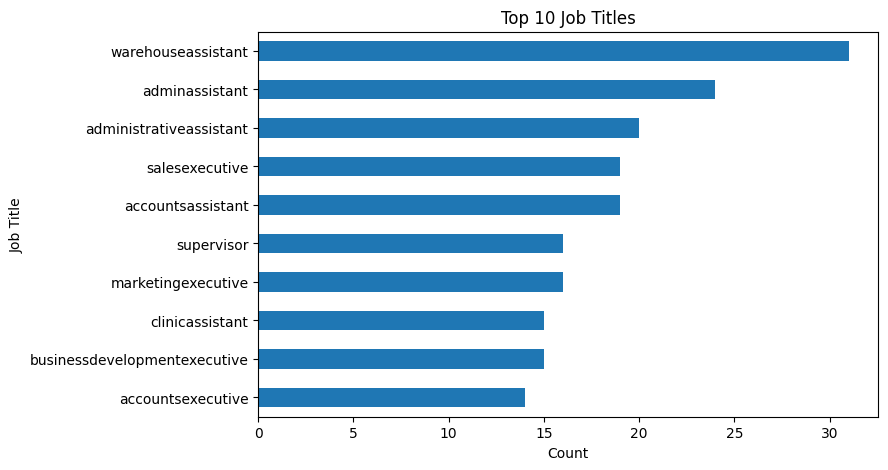

In [127]:
import matplotlib.pyplot as plt

title_counts_cleaned.head(10).plot(
    kind="barh", x="title_cleaned", y="count", figsize=(8, 5), legend=False
)
plt.gca().invert_yaxis()
plt.title("Top 10 Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()


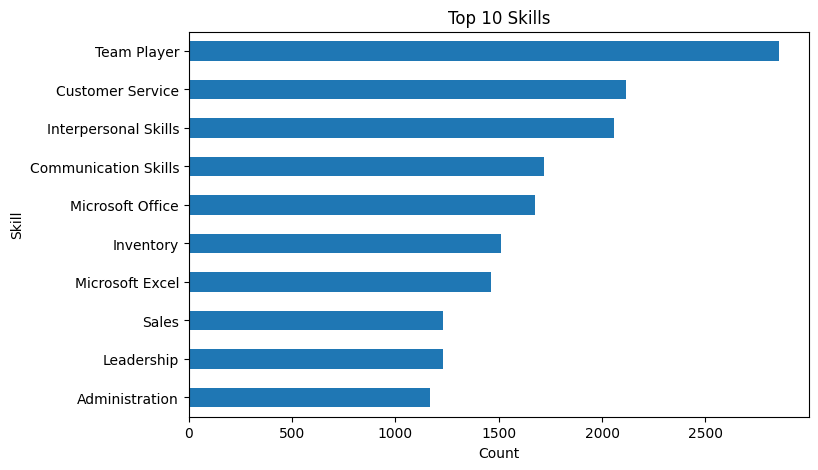

In [128]:
skills_df.head(10).plot(
    kind="barh", x="skill", y="count", figsize=(8, 5), legend=False
)
plt.gca().invert_yaxis()
plt.title("Top 10 Skills")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()


What are the most common entry-level job titles?
What are the most in-demand skills overall?
Which skills are most associated with each major job title?
Which job titles require the widest range of skills?

Most common entry-level job titles suggests what kinds of fresher jobs dominate the market.
Most in-demand skills overall shows the broadest employer demand.
Skills by major job title shows role-specific skill expectations.
Widest range of skills highlights jobs with broader competency requirements.


normalise title

In [129]:
jobs_df["title_cleaned"] = (
    jobs_df["title"]
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


move skills out of the list

In [130]:
jobs_df["skills"] = jobs_df["skills"].apply(
    lambda x: [s.strip() for s in x.split(",")] if isinstance(x, str) else x
)


Most Common Entry-Level Job Titles

In [131]:
top_titles = (
    jobs_df["title_cleaned"]
    .value_counts()
    .reset_index()
)

top_titles.columns = ["job_title", "count"]
top_titles.head(20)


,job_title,count
0,warehouse assistant,31
1,admin assistant,24
2,administrative assistant,20
3,sales executive,19
4,accounts assistant,19
5,marketing executive,16
6,supervisor,16
7,business development executive,15
8,clinic assistant,15
9,accounts executive,14


Most In-Demand Skills Overall

In [134]:
skill_counts = Counter(
    skill
    for skills in jobs_df["skills"]
    if isinstance(skills, list)
    for skill in skills
)

top_skills = (
    pd.DataFrame(skill_counts.items(), columns=["skill", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

top_skills.head(20)


,skill,count
0,Team Player,2857
1,Customer Service,2114
2,Interpersonal Skills,2059
3,Communication Skills,1718
4,Microsoft Office,1677
5,Inventory,1511
6,Microsoft Excel,1461
7,Sales,1232
8,Leadership,1231
9,Administration,1166


Skills Most Associated With Each Major Job Title

In [135]:
major_titles = jobs_df["title_cleaned"].value_counts().head(10).index

rows = []

for title in major_titles:
    subset = jobs_df[jobs_df["title_cleaned"] == title]
    counts = Counter(
        skill
        for skills in subset["skills"]
        if isinstance(skills, list)
        for skill in skills
    )
    
    for skill, count in counts.most_common(10):
        rows.append({
            "job_title": title,
            "skill": skill,
            "count": count
        })

title_skill_table = pd.DataFrame(rows)
title_skill_table


,job_title,skill,count
0,warehouse assistant,Warehousing,29
1,warehouse assistant,Housekeeping,29
2,warehouse assistant,Inventory,29
3,warehouse assistant,Physically Fit,27
4,warehouse assistant,Unloading,26
...,...,...,...
95,accounts executive,Accounts Payable,12
96,accounts executive,Microsoft Excel,11
97,accounts executive,Accounts Receivable,10
98,accounts executive,Able To Work Independently,10


Job Titles Requiring the Widest Range of Skills

In [137]:
unique_skills_by_title = []

for title, group in jobs_df.groupby("title_cleaned"):
    unique_skills = {
        skill
        for skills in group["skills"]
        if isinstance(skills, list)
        for skill in skills
    }
    unique_skills_by_title.append({
        "job_title": title,
        "num_unique_skills": len(unique_skills),
        "posting_count": len(group)
    })

unique_skills_by_title = (
    pd.DataFrame(unique_skills_by_title)
    .sort_values(["num_unique_skills", "posting_count"], ascending=[False, False])
)

unique_skills_by_title.head(20)


,job_title,num_unique_skills,posting_count
977,business development executive,110,15
3471,marketing executive,99,16
361,admin assistant,85,24
444,administrative assistant,80,20
4797,sales executive,76,19
5863,warehouse assistant,75,31
4248,project engineer,74,9
4864,sales manager,70,8
289,accounts assistant,68,19
870,brand ambassador,64,9


## data related roles analysis

In [ ]:
data_keywords = [
    "data analyst",
    "data analytics",
    "data scientist",
    "data science",
    "data engineer",
    "business analyst",
    "business intelligence",
    "bi analyst",
    "bi developer",
    "machine learning",
    "ml engineer",
    "ai engineer",
    "artificial intelligence",
    "analytics engineer",
    "research analyst",
]

pattern = "|".join(data_keywords)

data_jobs_df = jobs_df[
    jobs_df["title"].str.lower().str.contains(pattern, na=False, regex=True)
].copy()

# normalized version of job titles for the data-related jobs subset

data_jobs_df["title_cleaned"] = (
    data_jobs_df["title"]
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(data_jobs_df.shape)
data_jobs_df[["title", "skills", "avg_salary"]].head()


(29, 21)


,title,skills,avg_salary
34,Outreach Data Analyst,"[Tableau, Microsoft Excel, Data Analysis, Abil...",4000
389,Junior Functional Business Analyst (Cum Softwa...,"[Wealth Management, System Implementation, UAT...",3050
2002,Research Analyst - Quantitative Strategies,"[Machine Learning, Quantitative Research, Phys...",15998
2354,Physical AI Engineer,"[TensorFlow, Machine Learning, Hospitals, Dent...",5500
6220,"Business Analyst (Java, JavaScript, SQL, AWS C...","[technology consulting, Data Analysis, AWS, Bu...",5250


Most common data-related titles

In [141]:
data_title_counts = (
    data_jobs_df["title_cleaned"]
    .value_counts()
    .reset_index()
)

data_title_counts.columns = ["job_title", "count"]
data_title_counts.head(20)


,job_title,count
0,junior business analyst,2
1,outreach data analyst,1
2,k01 business analyst,1
3,research analyst,1
4,senior data analyst,1
5,data analyst,1
6,business analyst 2 hc banking,1
7,admin assistant data analytics,1
8,research associate research assistant data ana...,1
9,research associate artificial intelligence com...,1


Most common skills in data-related jobs

In [ ]:
skill_col = "skills_clean" if "skills_clean" in data_jobs_df.columns else "skills"

data_skill_counts = Counter(
    skill
    for skills in data_jobs_df[skill_col]
    if isinstance(skills, list)
    for skill in skills
)

top_data_skills = (
    pd.DataFrame(data_skill_counts.items(), columns=["skill", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

top_data_skills.head(20)


,skill,count
0,SQL,14
1,Data Analysis,12
2,Python,12
3,Business Analysis,10
4,Business Requirements,10
5,Test Cases,9
6,Microsoft Excel,9
7,Data Analytics,9
8,Machine Learning,8
9,Business Analyst,8


Salary summary for data-related jobs

In [143]:
data_jobs_df["avg_salary"].describe()


count           29.0
mean     5493.034483
std      2431.171065
min           3050.0
25%           4350.0
50%           5000.0
75%           6000.0
max          15998.0
Name: avg_salary, dtype: Float64

salary_by_data_title

In [144]:
salary_by_data_title = (
    data_jobs_df.groupby("title_cleaned")["avg_salary"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values(["median", "count"], ascending=[False, False])
    .reset_index()
)

salary_by_data_title.head(20)


,title_cleaned,count,mean,median,min,max
0,research analyst quantitative strategies,1,15998.0,15998.0,15998,15998
1,junior business analyst,2,7625.0,7625.0,6250,9000
2,analytics engineer data services python prompt...,1,7500.0,7500.0,7500,7500
3,senior data analyst,1,7500.0,7500.0,7500,7500
4,research associate artificial intelligence com...,1,6000.0,6000.0,6000,6000
5,research associate machine learning and automa...,1,6000.0,6000.0,6000,6000
6,research associate research assistant data ana...,1,6000.0,6000.0,6000,6000
7,business analyst banking,1,5750.0,5750.0,5750,5750
8,junior business analyst calypso,1,5750.0,5750.0,5750,5750
9,physical ai engineer,1,5500.0,5500.0,5500,5500


Skills associated with each major data title

In [145]:
major_data_titles = data_jobs_df["title_cleaned"].value_counts().head(10).index

rows = []

for title in major_data_titles:
    subset = data_jobs_df[data_jobs_df["title_cleaned"] == title]
    counts = Counter(
        skill
        for skills in subset[skill_col]
        if isinstance(skills, list)
        for skill in skills
    )
    
    for skill, count in counts.most_common(10):
        rows.append({
            "job_title": title,
            "skill": skill,
            "count": count
        })

data_title_skill_table = pd.DataFrame(rows)
data_title_skill_table


,job_title,skill,count
0,junior business analyst,User Stories,2
1,junior business analyst,Business Analysis,2
2,junior business analyst,Agile,2
3,junior business analyst,Test Cases,2
4,junior business analyst,Accounting,2
...,...,...,...
95,research associate artificial intelligence com...,Constraint Handling Rules,1
96,research associate artificial intelligence com...,Artificial Intelligence,1
97,research associate artificial intelligence com...,Semantics,1
98,research associate artificial intelligence com...,PyTorch,1


Work type / contract type for data jobs

In [149]:
data_jobs_df["work_type"].value_counts(dropna=False)

work_type
Full Time    28
Part Time     1
Name: count, dtype: int64

In [150]:
data_jobs_df["contract_type"].value_counts(dropna=False)

contract_type
Contract     15
Permanent    10
Unknown       3
Temporary     1
Name: count, dtype: int64

Plots

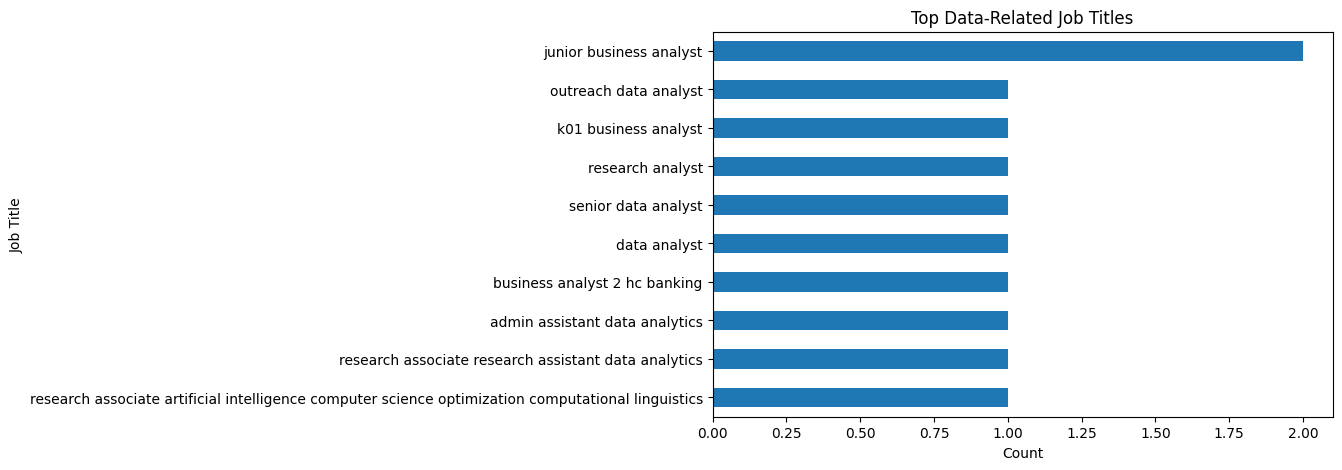

In [151]:
import matplotlib.pyplot as plt

data_title_counts.head(10).plot(
    kind="barh", x="job_title", y="count", figsize=(8, 5), legend=False
)
plt.gca().invert_yaxis()
plt.title("Top Data-Related Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()


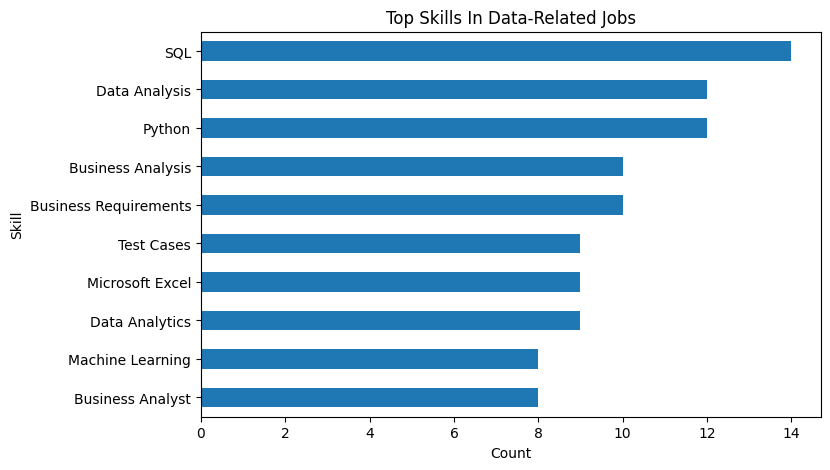

In [152]:
top_data_skills.head(10).plot(
    kind="barh", x="skill", y="count", figsize=(8, 5), legend=False
)
plt.gca().invert_yaxis()
plt.title("Top Skills In Data-Related Jobs")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()


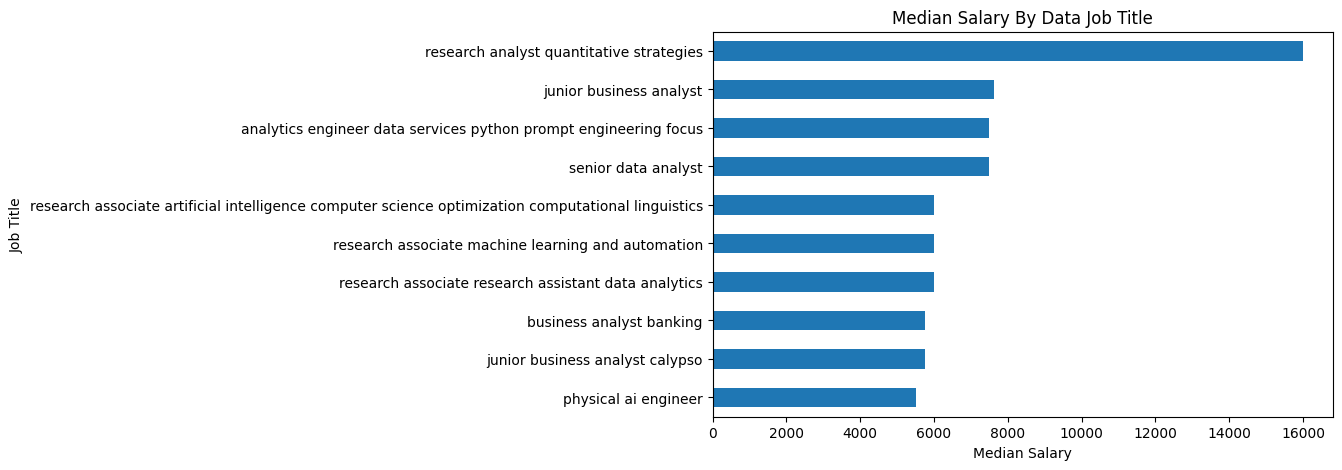

In [153]:
salary_by_data_title.head(10).plot(
    kind="barh", x="title_cleaned", y="median", figsize=(8, 5), legend=False
)
plt.gca().invert_yaxis()
plt.title("Median Salary By Data Job Title")
plt.xlabel("Median Salary")
plt.ylabel("Job Title")
plt.show()
